# New Plot for the Paper

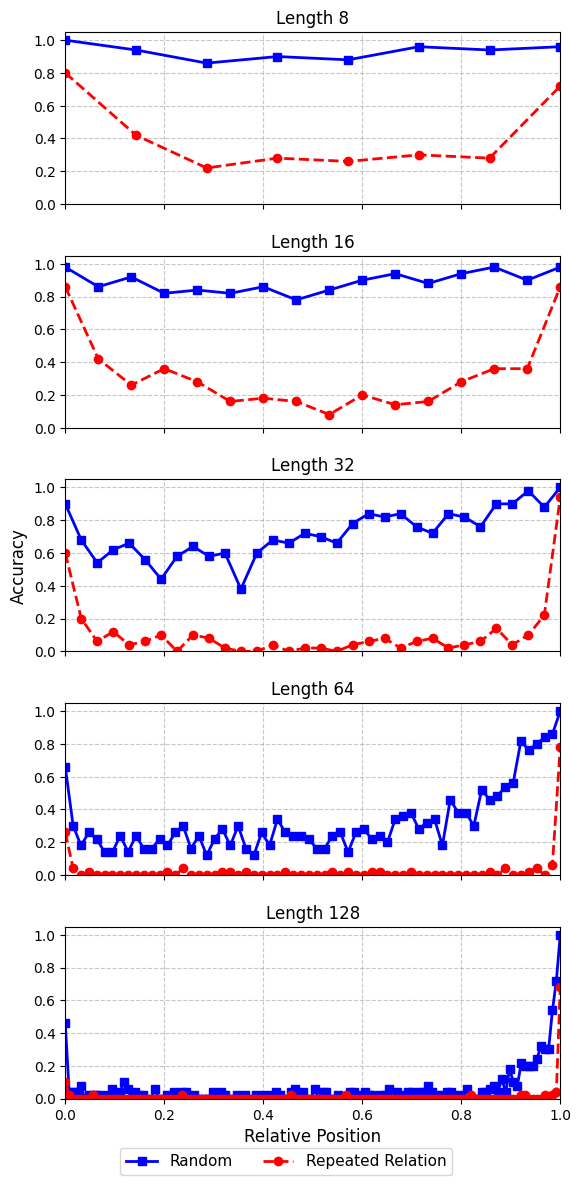

In [3]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re

# Path to the pickle file generated by the evaluation script
pickle_file = "results_new/accuracy_by_position.pkl"

# Load the pickle data
with open(pickle_file, 'rb') as f:
    data = pickle.load(f)

# Extract the dataset info and accuracy data
dataset_info = data['dataset_info']
accuracy_by_position = data['accuracy_by_position']

# Function to extract sequence length from filename/label
def extract_length(label):
    # Try to find a number at the beginning of the label
    match = re.search(r'^(\d+)', label)
    if match:
        return int(match.group(1))
    return None

# Group datasets by their sequence length
grouped_datasets = {}

for i, info in enumerate(dataset_info):
    # Extract the sequence length
    length = extract_length(info['label'])
    if length is None:
        length = info['length']  # Use stored length if extraction fails
    
    if length not in grouped_datasets:
        grouped_datasets[length] = []
    
    # Determine if it's a "same_relation" dataset or regular
    is_same_relation = 'same_relation' in info['label'].lower()
    
    grouped_datasets[length].append({
        'info': info,
        'accuracy': accuracy_by_position[i],
        'is_same_relation': is_same_relation
    })

# Create a single figure with 5 subplots (one for each length)
fig, axes = plt.subplots(5, 1, figsize=(6, 12), sharex=True)  # Now sharing x-axis

# Sort lengths to ensure consistent order (8, 16, 32, 64, 128)
sorted_lengths = sorted(grouped_datasets.keys())

# Create empty handles and labels for the legend
legend_handles = []
legend_labels = []

# Create each subplot
for i, length in enumerate(sorted_lengths):
    ax = axes[i]
    datasets = grouped_datasets[length]
    
    for dataset in datasets:
        info = dataset['info']
        acc = dataset['accuracy']
        is_same_relation = dataset['is_same_relation']
        
        # Skip if accuracy data is empty
        if acc.empty:
            continue
        
        # Normalize positions to 0-1 range
        # Important: Subtract 1 from position to align correctly (positions are 1-indexed)
        original_positions = acc.index.tolist()
        normalized_positions = [(pos-1)/(length-1) for pos in original_positions]
        
        # Choose line style, color, and label based on dataset type
        label = "Repeated Relation" if is_same_relation else "Random"
        linestyle = '--' if is_same_relation else '-'
        marker = 'o' if is_same_relation else 's'
        color = 'red' if is_same_relation else 'blue'
        
        # Plot accuracy by normalized position
        line = ax.plot(normalized_positions, acc.values, 
                marker=marker, linestyle=linestyle, 
                linewidth=2, color=color)
        
        # Only add to legend handles/labels once (for the first subplot)
        if i == 0:
            legend_handles.append(line[0])
            legend_labels.append(label)
    
    ax.set_title(f'Length {length}', fontsize=12)
    
    # Only add ylabel to the middle subplot
    if i == 2:
        ax.set_ylabel('Accuracy', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.05)
    
    # Set x-ticks to normalized positions (0 to 1)
    ax.set_xlim(0, 1.0)
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_xticklabels([f'{x:.1f}' for x in np.arange(0, 1.1, 0.2)])
    
    # Only add xlabel to the bottom subplot
    if i == len(sorted_lengths) - 1:
        ax.set_xlabel('Relative Position', fontsize=12)

# Add a single legend at the bottom of the figure
fig.legend(legend_handles, legend_labels, 
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.01), 
           fontsize=11, frameon=True)

# Add extra space at the bottom for the legend
plt.tight_layout()
fig.subplots_adjust(hspace=0.3, bottom=0.08)

# Save the plot
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}/accuracy_relative_positions.png", dpi=300)
plt.show()